<a href="https://colab.research.google.com/github/zyuneee/portfolio/blob/main/%EC%96%BC%EA%B5%B4_%EC%83%9D%EC%84%B1_AI_%EB%A7%8C%EB%93%A4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "drive/MyDrive/Colab Notebooks/Users/byeonhyejeong/kaggle.json"

In [7]:
!kaggle datasets download -d jessicali9530/celeba-dataset

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:13<00:00, 289MB/s]
100% 1.33G/1.33G [00:13<00:00, 105MB/s]


In [8]:
!unzip -q celeba-dataset.zip -d .

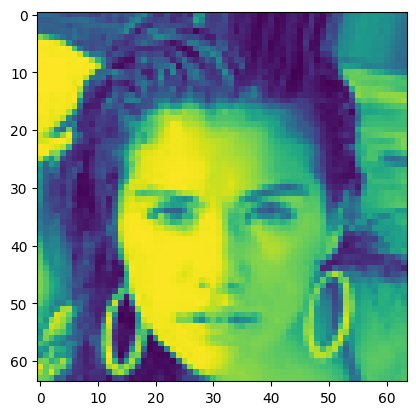

(50000, 64, 64)


In [9]:
from PIL import Image #이미지 숫자로 변환


import os
import numpy as np

파일리스트 = os.listdir('/content/img_align_celeba/img_align_celeba')

images= []


for i in 파일리스트[0:50000]:
  숫자화된거 = Image.open('/content/img_align_celeba/img_align_celeba/' + i).crop((20,30,160,180)).convert('L').resize((64,64))
  images.append(np.array(숫자화된거))

#crop((20,30,160,180)) : 가장자리 여백 지우기

import matplotlib.pyplot as plt
plt.imshow(images[1])
plt.show()


images = np.array(images)
print(images.shape)

In [ ]:
images = np.divide(images,255)
images = images.reshape(50000,64,64,1)
print(images.shape)

(50000, 64, 64, 1)


In [10]:
import tensorflow as tf

In [12]:
import tensorflow as tf

generator = tf.keras.models.Sequential([
  tf.keras.layers.Dense(4 * 4 * 256, input_shape=(100,) ),
  tf.keras.layers.Reshape((4, 4, 256)),
  tf.keras.layers.Conv2DTranspose(256, 3, strides=2, padding='same'),
  tf.keras.layers.LeakyReLU(alpha=0.2),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same'),
  tf.keras.layers.LeakyReLU(alpha=0.2),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same'),
  tf.keras.layers.LeakyReLU(alpha=0.2),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding='same', activation='sigmoid')
])


discriminator = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(64, (3,3), strides=(2, 2), padding='same', input_shape=[64,64,1]),
  tf.keras.layers.LeakyReLU(alpha=0.2),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Conv2D(64, (3,3), strides=(2, 2), padding='same'),
  tf.keras.layers.LeakyReLU(alpha=0.2),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation='sigmoid')
])

In [20]:
def predict_pic():
  랜덤숫자 = np.random.uniform(-1,1,size=(8,100))
  예측 =generator.predict(랜덤숫자)

#print(예측.shape)
  for i in range(8):
    plt.subplot(2,5,i+1)
    plt.imshow(예측[i].reshape(64,64), cmap='gray')
    plt.axis('off')

  plt.tight_layout()
  plt.show()

In [24]:
# 학습 전 컴파일
GAN = tf.keras.models.Sequential([generator, discriminator])

discriminator.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

GAN.compile(optimizer='adam', loss='binary_crossentropy')


지금 epoch 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


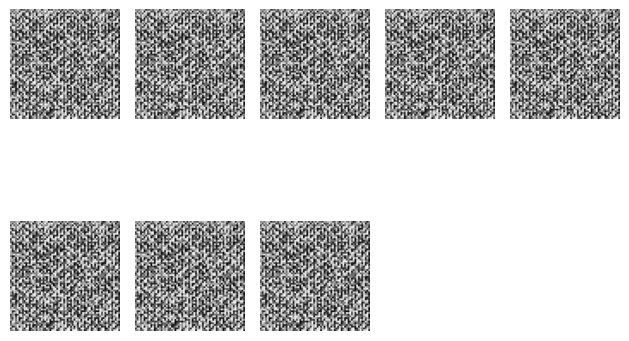

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

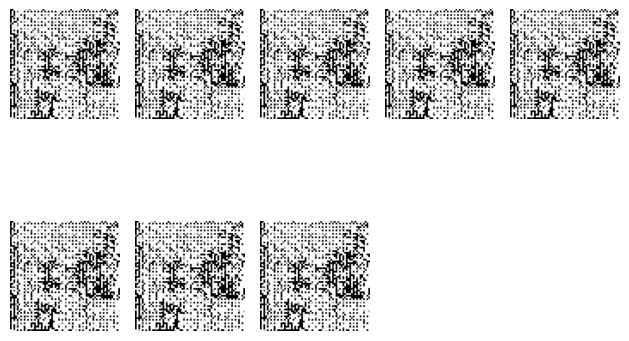

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

for j in range(300):
  print(f'지금 epoch {j}')
  predict_pic()

  for i in range(50000//128):

  #학습
    x데이터 = images

  #discriminator

    진짜사진들 = x데이터[i*128:(i+1)*128]
    라벨1 = np.ones(shape=(128,1))
    discriminator.trainable = True
    loss1= discriminator.train_on_batch(진짜사진들,라벨1)


    랜덤숫자 = np.random.uniform(-1,1,size=(128,100))
    가짜사진 = generator.predict(랜덤숫자)
    라벨0 = np.zeros(shape=(128,1))

    loss2 = discriminator.train_on_batch(가짜사진,라벨0)

  # generator 학습
    랜덤숫자 = np.random.uniform(-1,1,size=(128,100))
    라벨1 = np.ones(shape=(128,1))
    discriminator.trainable = False
    loss3= GAN.train_on_batch(랜덤숫자,라벨1)
